# Demonstration of Allen-Cahn phase-field model

In [1]:
#Install Firedrake if not installed
try:
    from firedrake import *
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/firedrake-install-release-real.sh" -O "/tmp/firedrake-install.sh" && bash "/tmp/firedrake-install.sh"
    from firedrake import *

from firedrake.pyplot import tripcolor
import matplotlib.pyplot as plt

--2026-06-17 20:14:43--  https://fem-on-colab.github.io/releases/firedrake-install-release-real.sh
Resolving fem-on-colab.github.io (fem-on-colab.github.io)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to fem-on-colab.github.io (fem-on-colab.github.io)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4767 (4.7K) [application/x-sh]
Saving to: ‘/tmp/firedrake-install.sh’

/tmp/firedrake-inst 100%[===================>]   4.66K  --.-KB/s    in 0s      

2026-06-17 20:14:43 (48.2 MB/s) - ‘/tmp/firedrake-install.sh’ saved [4767/4767]

+ INSTALL_PREFIX=/usr/local
++ awk -F/ '{print NF-1}'
++ echo /usr/local
+ INSTALL_PREFIX_DEPTH=2
+ PROJECT_NAME=fem-on-colab
+ SHARE_PREFIX=/usr/local/share/fem-on-colab
+ FIREDRAKE_INSTALLED=/usr/local/share/fem-on-colab/firedrake.installed
+ [[ ! -f /usr/local/share/fem-on-colab/firedrake.installed ]]
+ PYBIND11_INSTALL_SCRIPT_PATH=https://github.com/fem-on-colab/fem-on-colab.github.io/raw/2cc1

In [2]:
from firedrake import * # Works
import math # Works
from timeit import default_timer as timer # Works

In [3]:
# Parameters
interface_width = .01
interfacial_energy_SiCAr = 2.24  #energy between SiC and Ar in J/m^2 (inc. from 2.24)
interfacial_energy_SiCSiC = 0.5  #energy between two SiC phases in J/m^2 (inc. from .1)
interface_mobility = 50 # This parameter controls the speed at which the phase interface evolves or moves.

dt = Constant(1e-1)
t0 = 0
t_final = 1

M_phi = 1e-7 # Phase field mobility constant (dec. from 1e-6)
T = 1773 # Temp.
RT = 8.314*T # ideal gas const. and Temp.

D = 1.19e-3 #Diffusion coefficient #m^2/s − Self diffusion of Ar at 1atm, 1600 K

In [38]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [39]:
import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks/my_modules')

In [40]:
import thermo_potentials
potential_model = thermo_potentials.build_potential()
print(potential_model)

In [46]:
from thermo_potentials import build_potential, equil_partition, quadratic_collection
from thermo_potentials import collect_sympy_phases, build_ideal_solution_elastic, build_interface_phase
from thermo_potentials import potential, sympy_potential, diag_scale, solve_KKT
from thermo_potentials import add_ideal_mixing, add_hyperelastic

def build_potential():
  T = 1273 #Kelvin
  RT = 8.314*T
  x_SiC_gas = 3.8288e-2 #1MTS:1H2:1Ar

  mu0_SiC_solid = -127610 #T=1000C # chem. pot. for solid SiC
  mu0_Ar = -215263 #T=100C # chem. pot. for Ar
  mu0_SiC_gas = mu0_SiC_solid -RT*np.log(x_SiC_gas) # chem. pot. of SiC gas
  print(mu0_SiC_gas)

  rho_SiC = 3.09 / 40.11 * 1e6 # 3.21 g/cm^3 / 40.11 g/mol = .08 mol / cm^3 # density of SiC
  kappa_SiC = 186e9*1e-5 # elastic modulus for SiC
  rho_Ar = 101e3 / RT # n/V = P / RT = 101 kPa / (8.314 J/(mol K) * 1600 K) = 7.5 mol / m^3 # density of Ar

  a_a = build_ideal_solution_elastic ([mu0_SiC_solid] , T=T, vi = 1/rho_SiC,
kappa = kappa_SiC, phase_id = 'a')

  # Add a second phase for Argon gas
  a_b = build_ideal_solution_elastic([mu0_Ar], T=T, vi=1/rho_Ar, kappa=1e5, phase_id='b') # Assuming a small bulk modulus for gas

# Connects all these defined phases into a single collection
  a_full = collect_sympy_phases([a_a, a_b] , rename=False) # Include the new phase a_b

  # Adjust y0 to match the variables of a_full (V_a, c0_a, V_b, c0_b)
  # The error message '[V_a, c0_a] = _Dummy_59' implies an expected order of V_a then c0_a.
  y0 = [1, rho_SiC, 1, rho_Ar] # Initial guess for [V_a, c0_a, V_b, c0_b]

  # Adjust vars_out to reflect the variables of both phases
  a_quad = quadratic_collection(a_full , [ 'V_a', 'c0_a', 'V_b', 'c0_b'] , y0 = y0) # Creates quadratic approximation of the collected phases using 'y0' array and specific phase labels.

  return a_quad

a_quad = build_potential()
print(a_quad)

-93079.3501811261


In [47]:
# Create a mesh with resolution of approximately the interface width

mesh_resolution = int(1/(2*interface_width))
mesh = UnitSquareMesh(mesh_resolution, mesh_resolution)
x = SpatialCoordinate(mesh)

In [52]:
# Define the function space and instanciate the function and test_functions
V = FunctionSpace(mesh, "CG", 1, name="phase")

phase = Function(V)
phase_old = Function(V) # Used to store previous time step
test_phase = TestFunction(V)

In [50]:
# Phase field functions

def multiphase(p, interface_width): #calculates terms related to the interface between different phases
    def antisymmetric_gradient(pa, pb): # quantifies energy with the transition between two phase fields
        return 3*(interface_width**2*( pa*gr(pb) - pb*gr(pa) )**2 + pa**2*pb**2*(1+50*(pa+pb-1)**2) )

interface_area = as_vector(multiphase(phi, interface_width))
interfacial_energy = as_vector ([ interfacial_energy_SiCSiC]*3 + [interfacial_energy_SiCAr ]*3) # this vector holds all interfacial energy densities for each type of interface in system
interfacial_energy = interfacial_energy/interface_width #values scaled by 'interface_width'

# Sums energy contributions from all interfaces across the domain
interface_energy = inner(interfacial_energy , interface_area) # total interfacial energy calculated as dot prod. of 'interfacial_energy densities' and the 'interface_area' terms
#interface_energy = inner(as_vector ([ interfacial_energy_SiCSiC / interface_width] *comb(m,2) ) , as_vector(interface_area))

# Thermodynamic response (potential.grad) - thermo. pot. differentiated with respect to species conc. and transformed phase field variables

response = a_quad.grad(list (c)+p_phase) #

F_phase_interface = - interface_mobility* interface_energy * dA

F = (phase-phase_old)*test_phase - dt*F_phase_interface
F = F*dx

# Diffusion Calculation
#D = inner(as_vector(phi) ,as_vector([1e-5,1e-5,1e-5,1e-3])) #phase-dependent diffusion coefficient
#J = -D/RT*gr(mu) #diffusion flux using Fick's 1st law - species move down the gradient of their chem. pot.
#F_diffusion = as_vector([inner(J[i ,:] , gr(test_c[ i ]) ) # Construction of weak form of diffusion equation for FEM
#for i in range(J .ufl_shape [0]) ])
#F_diffusion = elem_div(F_diffusion , c_scale)

NameError: name 'phi' is not defined

In [ ]:
# Set initial condition to be a circle in the middle of the mesh
t = t0

def tanh_profile(x):
  return .5*(1.-tanh(x/(2.*interface_width)))

def bubble(r, centre):
  c = as_vector(centre)
  d = sqrt(inner(x-c, x-c))
  return tanh_profile(d - r)

bub1 = bubble(r = .3, centre = [.5,.5])

phase.interpolate(bub1)

Coefficient(WithGeometry(FunctionSpace(<firedrake.mesh.MeshTopology object at 0x7b2e637dfad0>, FiniteElement('Lagrange', triangle, 1), name='phase'), Mesh(VectorElement(FiniteElement('Lagrange', triangle, 1), dim=2), 0)), 3)

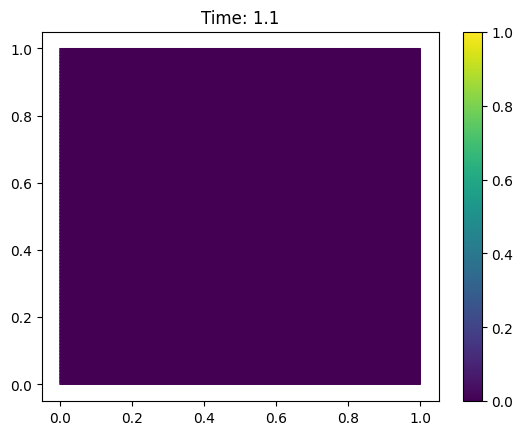

In [ ]:
# Use tripcolor and set vmin and vmax for the color mapping
# TODO: Improve the performance of this funciton and make an interactive annimation.

def plot_phase(t):
  fig, axes = plt.subplots()
  colors = tripcolor(phase, axes=axes, vmin=0, vmax=1)
  axes.set_title(f"Time: {round(t,1)}")
  fig.colorbar(colors)
  plt.show()

plot_phase(t)

Current Time: 1.00e-01


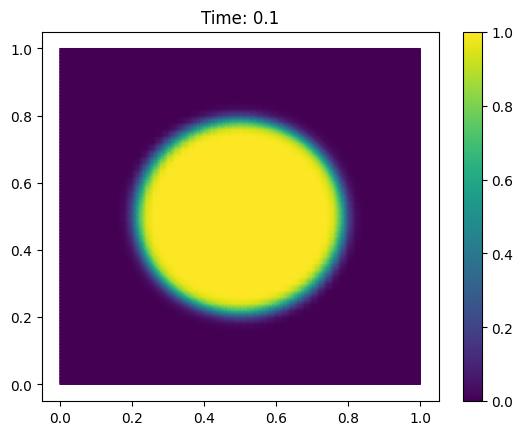

Current Time: 2.00e-01


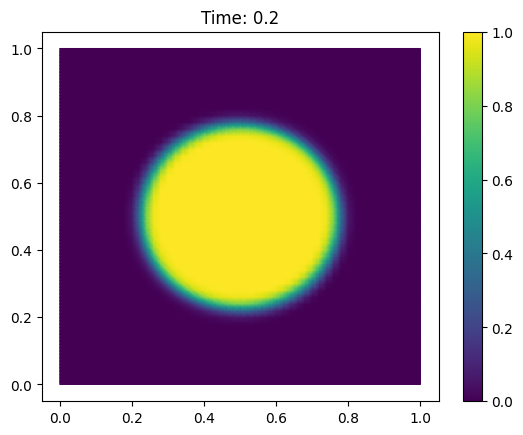

Current Time: 3.00e-01


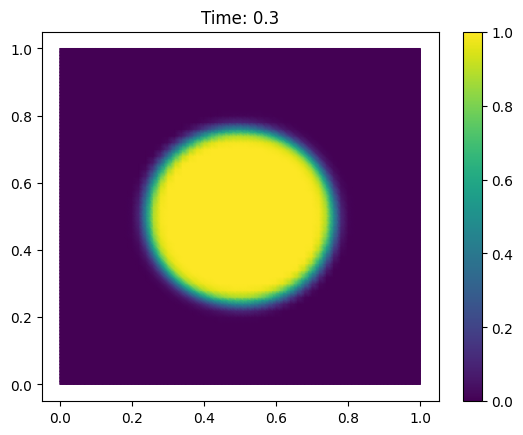

Current Time: 4.00e-01


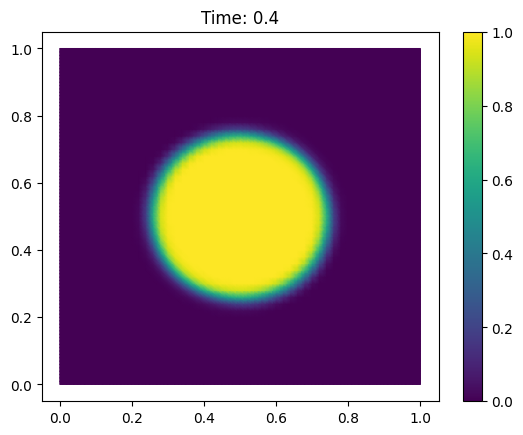

Current Time: 5.00e-01


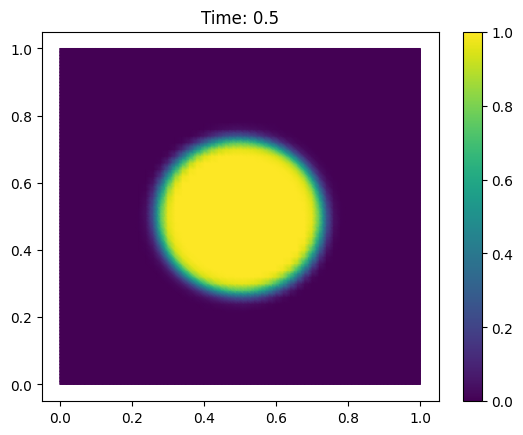

Current Time: 6.00e-01


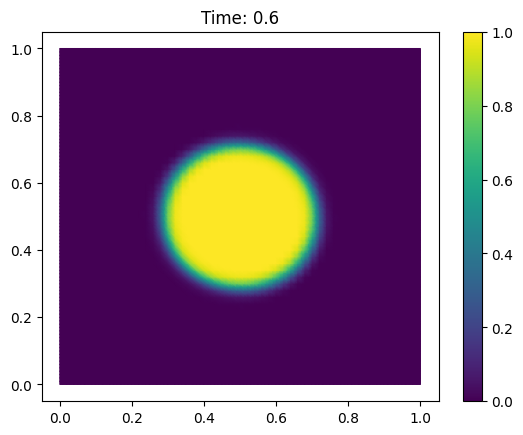

Current Time: 7.00e-01


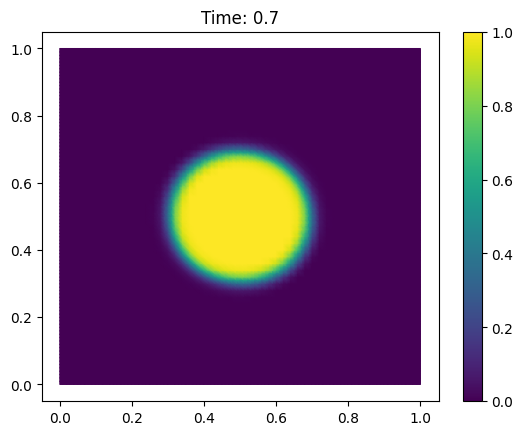

Current Time: 8.00e-01


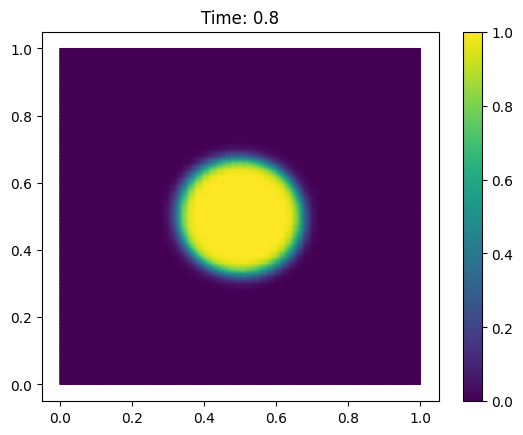

Current Time: 9.00e-01


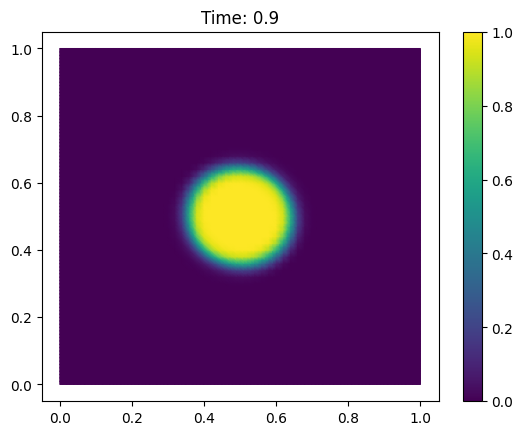

Current Time: 1.00e+00


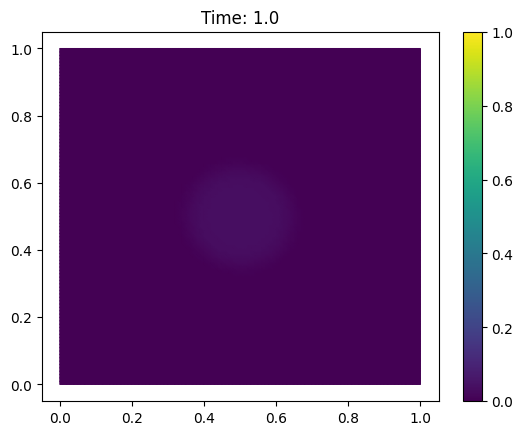

Current Time: 1.10e+00


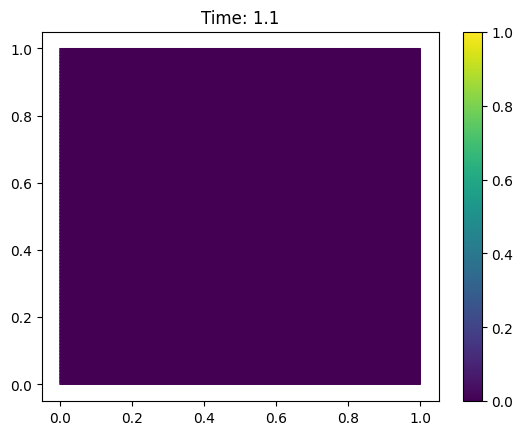

In [ ]:
while t<t_final:
    phase_old.assign(phase)
    t += dt(0)
    print(f"Current Time: {round(t,2):.2e}")

    solve(F == 0, phase, solver_parameters={"ksp_type": "preonly", "pc_type": "lu"})
    plot_phase(t)